<h1>Núcleo 1 Text Mining aplicado à Adaptação Curricular</h1>
<p>Datasets: <b>CLEAR Corpus</b> (complexidade textual), <b>Bloom's Taxonomy</b> (intenção pedagógica em inglês) e conjuntos de teste rotulados à mão em português (Bloom e Simpson)</p>
<p>Aluna: Maria Clara Ribeiro Di Bragança</p>

<h1>Fase 1 Business Understanding</h1>

<h2>Contexto e problema de negócio</h2>
<p>O CogniKids é uma plataforma educacional para crianças neurodivergentes (TEA, TDAH e Dislexia). O problema é que o professor escreve uma única atividade em texto para a turma inteira, mas cada criança processa esse texto de um jeito diferente: uma criança com dislexia se beneficia de frases curtas e simples, enquanto uma criança com TEA precisa de instruções em passo a passo, concretas e sem ambiguidade. Reescrever a mesma atividade em vários formatos, para cada professor e cada turma, não é sustentável, e por isso o sistema precisa antes entender o que o texto do professor está pedindo, para só depois adaptar o formato (o conteúdo pedagógico nunca muda, só a forma de apresentar).</p>

<h2>Objetivo de negócio</h2>
<p>Descobrir se é possível extrair automaticamente, do texto de uma atividade, três propriedades que orientam a adaptação:</p>
<p><b>Complexidade textual</b>: o texto está acima do nível de leitura da criança?</p>
<p><b>Intenção pedagógica (domínio cognitivo, Taxonomia de Bloom)</b>: o professor quer que o aluno memorize, explique, analise ou crie? Essa distinção importa porque uma adaptação que simplifica demais pode trocar, sem querer, um objetivo de análise por um de memorização.</p>
<p><b>Demanda motora (domínio psicomotor, Taxonomia de Simpson)</b>: a atividade pede só raciocínio ou também execução física, como montar ou recortar? Isso importa porque parte do público tem dificuldade de coordenação motora, e uma atividade com demanda motora alta precisa de um tipo de adaptação diferente de uma atividade só cognitiva.</p>

<h2>Objetivo da mineração de dados</h2>
<p>Usar datasets públicos para verificar se uma métrica calculável de complexidade e uma classificação de intenção pedagógica conseguem caracterizar o texto de entrada de forma confiável, sem depender de um modelo pesado ou de serviço externo, e estender a mesma abordagem para o domínio psicomotor, onde não existe dataset público em nenhum idioma.</p>

<h2>Perguntas estratégicas de negócio</h2>
<p>Existe correlação suficiente entre uma métrica calculável de complexidade e a avaliação humana de facilidade de leitura?</p>
<p>É possível classificar a intenção pedagógica de um texto escrito em português sem depender de um dataset em outro idioma?</p>
<p>Um sistema baseado em regras de verbos resolve o problema melhor do que um modelo treinado em inglês aplicado a texto em português?</p>
<p>É possível identificar, com o mesmo tipo de sistema baseado em regras, se uma atividade tem demanda motora (domínio psicomotor), mesmo sem nenhum dataset disponível para esse domínio?</p>

<h1>Fase 2 Data Understanding</h1>
<p>Importando as bibliotecas e olhando cada dataset antes de decidir qualquer preparação: CLEAR Corpus (complexidade), Bloom's Taxonomy (intenção pedagógica em inglês) e os conjuntos de teste em português.</p>

In [1]:
import re
import json
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyphen
import textstat

np.random.seed(42)
DATASETS = "../../datasets/raw"

<h2>2.1 CLEAR Corpus: complexidade textual</h2>
<p>O CLEAR Corpus é um dataset público com trechos de texto em inglês, cada um avaliado por leitores humanos quanto à facilidade de leitura. As colunas usadas aqui são três:</p>
<p><b>Excerpt</b>: o trecho de texto.</p>
<p><b>BT Easiness</b>: nota de facilidade de leitura dada por avaliação humana (valores maiores indicam texto mais fácil).</p>
<p><b>Flesch-Kincaid-Grade-Level</b>: métrica calculável que estima a série escolar necessária para entender o texto (valores maiores indicam texto mais difícil), ou seja, não depende de avaliação humana.</p>
<p>A pergunta é se a métrica calculável consegue representar o julgamento humano, porque se conseguir, o sistema calcula a complexidade de qualquer texto novo sem precisar de avaliadores.</p>

In [2]:
clear_bruto = pd.read_csv(f"{DATASETS}/commonlit_clear_corpus/CLEAR.csv")
colunas_uteis = ["Excerpt", "Flesch-Kincaid-Grade-Level", "BT Easiness"]

print("Dimensão do dataset:", clear_bruto.shape)
print("Quantidade de colunas totais:", len(clear_bruto.columns))
print()
clear_bruto[colunas_uteis].info()

Dimensão do dataset: (4726, 40)
Quantidade de colunas totais: 40

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4726 entries, 0 to 4725
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Excerpt                     4724 non-null   object 
 1   Flesch-Kincaid-Grade-Level  4724 non-null   float64
 2   BT Easiness                 4724 non-null   float64
dtypes: float64(2), object(1)
memory usage: 110.9+ KB


In [3]:
faltantes = clear_bruto[colunas_uteis].isnull().sum()
print(pd.DataFrame({"ausentes": faltantes, "percentual": (faltantes / len(clear_bruto) * 100).round(3)}))
print()
clear_bruto[["Flesch-Kincaid-Grade-Level", "BT Easiness"]].describe().round(3)

                            ausentes  percentual
Excerpt                            2       0.042
Flesch-Kincaid-Grade-Level         2       0.042
BT Easiness                        2       0.042



,Flesch-Kincaid-Grade-Level,BT Easiness
count,4724.000,4724.000
mean,9.508,-0.958
std,4.326,1.034
min,-1.040,-3.676
25%,6.560,-1.697
50%,9.350,-0.909
75%,11.972,-0.203
max,42.640,1.711


#### Interpretação

<p>O CLEAR Corpus tem 4.726 trechos e 40 colunas, das quais só 3 são usadas. As três tem exatamente 2 valores ausentes (0,042% do total), o que fica bem abaixo do limite de 1% da regra prática de dados faltantes e não é preocupante. O Flesch-Kincaid tem média de 9,508 e mediana de 9,35 (bem próximas), desvio padrão de 4,326, mínimo de -1,04 e máximo de 42,64, e 75% dos textos ficam abaixo de 11,97. A nota humana de facilidade tem média de -0,958, mediana de -0,909, mínimo de -3,676 e máximo de 1,711.</p>
<p>Isso indica que as duas variáveis são razoavelmente simétricas no centro, mas o máximo de 42,64 no Flesch-Kincaid não faz sentido como série escolar, e a hipótese é que seja um texto com frases muito longas ou sem pontuação (a fórmula divide palavras por frases, então uma pontuação rara infla o valor). Como isso acontece com poucos textos, o impacto para a próxima etapa é pequeno, mas é algo que requer atenção na hora de usar a fórmula em texto de professor, que pode vir sem ponto final.</p>

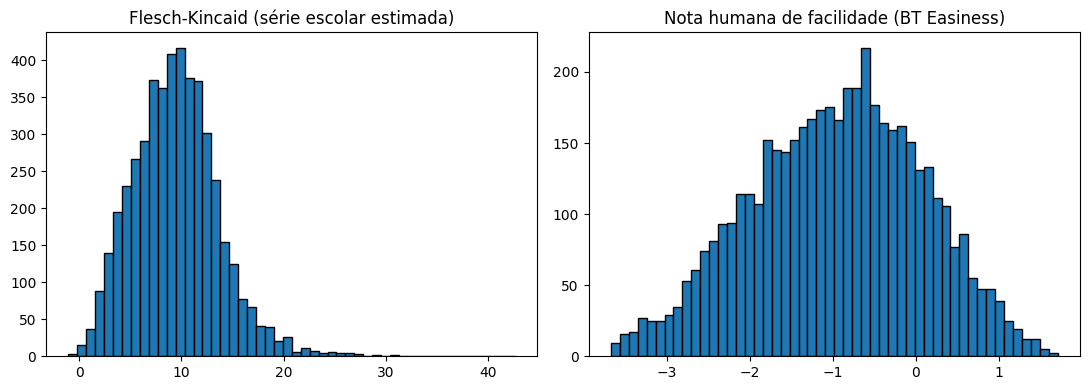

             count   mean  median
faixa_fk                         
até 5          691 -0.044   0.007
5 a 8         1069 -0.557  -0.495
8 a 11        1371 -0.992  -0.959
11 a 14       1018 -1.478  -1.479
acima de 14    575 -1.797  -1.838


In [4]:
clear_tmp = clear_bruto[colunas_uteis].dropna().copy()

fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].hist(clear_tmp["Flesch-Kincaid-Grade-Level"], bins=50, edgecolor="black")
eixos[0].set_title("Flesch-Kincaid (série escolar estimada)")
eixos[1].hist(clear_tmp["BT Easiness"], bins=50, edgecolor="black")
eixos[1].set_title("Nota humana de facilidade (BT Easiness)")
plt.tight_layout()
plt.show()

clear_tmp["faixa_fk"] = pd.cut(
    clear_tmp["Flesch-Kincaid-Grade-Level"],
    bins=[-5, 5, 8, 11, 14, 50],
    labels=["até 5", "5 a 8", "8 a 11", "11 a 14", "acima de 14"],
)
print(clear_tmp.groupby("faixa_fk", observed=True)["BT Easiness"].agg(["count", "mean", "median"]).round(3))

#### Interpretação

<p>Agrupando o Flesch-Kincaid em faixas, a nota humana de facilidade cai de forma contínua conforme o texto fica mais difícil: média de -0,044 na faixa até 5 (691 textos), -0,557 em 5 a 8 (1.069), -0,992 em 8 a 11 (1.371), -1,478 em 11 a 14 (1.018) e -1,797 acima de 14 (575). As medianas seguem o mesmo caminho (0,007 até -1,838), então não é efeito de alguns valores extremos.</p>
<p>Isso indica que a métrica calculável e a avaliação humana andam na mesma direção em toda a escala, ou seja, textos que a fórmula classifica como mais difíceis são tambem julgados como mais difíceis pelos leitores. A queda entre as faixas é menor no fim (de -1,478 para -1,797, uma diferença de 0,32, contra 0,43 a 0,51 nas faixas anteriores), o que sugere que a fórmula distingue melhor textos fáceis e médios do que textos muito difíceis. A correlação exata é medida na Fase 5, e a relação por faixa já indica que faz sentido usar a fórmula para ordenar textos por dificuldade.</p>

<h2>2.2 Bloom's Taxonomy: intenção pedagógica em inglês</h2>
<p>A Taxonomia de Bloom organiza os objetivos de aprendizagem em 6 níveis cognitivos, em ordem crescente de complexidade, e é ela que define o que o professor quer que o aluno faça com o conteúdo:</p>
<p><b>BT1 Lembrar</b>: recordar um fato (verbos típicos: listar, definir).</p>
<p><b>BT2 Entender</b>: explicar com as próprias palavras (explicar, resumir).</p>
<p><b>BT3 Aplicar</b>: usar o conhecimento em situação nova (resolver, calcular).</p>
<p><b>BT4 Analisar</b>: decompor e relacionar partes (comparar, categorizar).</p>
<p><b>BT5 Avaliar</b>: julgar segundo critérios (criticar, justificar).</p>
<p><b>BT6 Criar</b>: produzir algo original (elaborar, formular).</p>
<p>O dataset tem perguntas de atividades escolares em inglês, cada uma rotulada com o nível BT correspondente. Isso é um problema de classificação supervisionada multiclasse: dado o texto de uma pergunta, prever uma entre 6 categorias.</p>

In [5]:
bloom = pd.read_csv(f"{DATASETS}/blooms_taxonomy/blooms_taxonomy_dataset.csv")
print("Dimensão do dataset:", bloom.shape)
print("Colunas:", list(bloom.columns))
print("Valores ausentes:", bloom.isnull().sum().to_dict())
print("Perguntas duplicadas:", bloom.duplicated("Questions").sum())
print()

distribuicao = pd.DataFrame({
    "quantidade": bloom["Category"].value_counts().sort_index(),
    "proporção": bloom["Category"].value_counts(normalize=True).sort_index().round(4),
})
print(distribuicao)
print()
print("Palavras por pergunta:")
print(bloom["Questions"].str.split().str.len().describe().round(2))

primeira_palavra = bloom["Questions"].str.lower().str.split().str[0]
verbos_conferidos = ["explain", "define", "list", "compare", "describe", "discuss"]
selecao = primeira_palavra.isin(verbos_conferidos)
print()
print("Proporção de cada nível de Bloom entre as perguntas que começam com cada verbo (e o total de perguntas):")
tabela_verbos = pd.crosstab(primeira_palavra[selecao], bloom.loc[selecao, "Category"], normalize="index").round(2)
tabela_verbos["n"] = primeira_palavra[selecao].value_counts()
print(tabela_verbos)

Dimensão do dataset: (8767, 2)
Colunas: ['Questions', 'Category']
Valores ausentes: {'Questions': 0, 'Category': 0}
Perguntas duplicadas: 0

          quantidade  proporção
Category                       
BT1             2582     0.2945
BT2             1801     0.2054
BT3             1508     0.1720
BT4             1293     0.1475
BT5              783     0.0893
BT6              800     0.0913

Palavras por pergunta:
count    8767.00
mean       13.08
std         8.48
min         1.00
25%         8.00
50%        11.00
75%        16.00
max        75.00
Name: Questions, dtype: float64

Proporção de cada nível de Bloom entre as perguntas que começam com cada verbo (e o total de perguntas):
Category    BT1   BT2   BT3   BT4   BT5  BT6     n
Questions                                         
compare    0.03  0.31  0.06  0.52  0.08  0.0   298
define     0.75  0.21  0.02  0.03  0.00  0.0   189
describe   0.49  0.41  0.03  0.06  0.01  0.0   276
discuss    0.18  0.71  0.01  0.09  0.01  0.0   215

#### Interpretação

<p>O dataset tem 8.767 perguntas com 2 colunas, sem nenhum valor ausente (0%) e sem perguntas duplicadas (0). Os níveis são desbalanceados: BT1 tem 2.582 perguntas (29,45%), BT2 tem 1.801 (20,54%), BT3 tem 1.508 (17,20%), BT4 tem 1.293 (14,75%), BT6 tem 800 (9,13%) e BT5 tem 783 (8,93%), ou seja, o nível mais frequente tem 3,3 vezes mais exemplos do que o menos frequente. Um modelo que sempre prevê BT1 já teria 29,45% de acurácia. As perguntas são curtas, com mediana de 11 palavras (média de 13,08 e máximo de 75).</p>
<p>A tabela de primeiro verbo mostra um resultado importante para o resto do notebook: o nível de Bloom não é determinado só pelo verbo. Entre as 1.166 perguntas que começam com "explain", 44% são BT1, 39% são BT2 e 12% são BT4, e entre as 298 que começam com "compare", só 52% são BT4 (31% são BT2). Já "define" e "list" são mais consistentes, com 75% de BT1 cada. A hipótese é que quem rotulou levou em conta o assunto e o tamanho da pergunta, e não só o verbo, o que também limita o desempenho máximo de qualquer modelo treinado nesses dados (por isso o teto perto de 75% de acurácia que aparece na Fase 4). Isso também significa que a tabela de verbos das regras em português vem da teoria de Bloom, e não desse dataset, e que as duas fontes nem sempre concordam.</p>

<h2>2.3 Conjuntos de teste em português (Bloom e Simpson)</h2>
<p>Como não existe dataset público de Bloom em português, nem de Simpson em nenhum idioma, o desempenho do sistema em português só pode ser medido com instruções escolares rotuladas à mão. Existem dois conjuntos de tipos diferentes e a diferença entre eles é importante para a interpretação:</p>
<p><b>Conjunto de desenvolvimento</b> (teste_bloom_pt.json e teste_simpson_pt.json): foi usado para descobrir os erros da primeira versão das regras, e depois disso os verbos que faltavam foram cadastrados. Por isso o resultado nele tende a ser otimista, pois as regras foram ajustadas em cima dos próprios casos.</p>
<p><b>Conjunto cego</b> (teste_cego_bloom_pt.json e teste_cego_simpson_pt.json): instruções escritas com acento, como um professor escreve de verdade, e que não foram olhadas antes de fechar as regras da segunda versão. Esse é o conjunto que mede o desempenho esperado em uso real. Os rótulos dele foram definidos por quem montou o notebook, e não por professores, o que é uma limitação registrada na conclusão.</p>

In [6]:
def carregar_casos(nome):
    with open(f"dados_avaliacao/{nome}", encoding="utf-8") as arquivo:
        return [tuple(par) for par in json.load(arquivo)]

dev_bloom = carregar_casos("teste_bloom_pt.json")
dev_simpson = carregar_casos("teste_simpson_pt.json")
cego_bloom = carregar_casos("teste_cego_bloom_pt.json")
cego_simpson = carregar_casos("teste_cego_simpson_pt.json")

resumo = pd.DataFrame({
    "Bloom desenvolvimento": pd.Series([r for _, r in dev_bloom]).value_counts(),
    "Bloom cego": pd.Series([r for _, r in cego_bloom]).value_counts(),
}).fillna(0).astype(int).sort_index()
print(resumo)
print()
resumo_s = pd.DataFrame({
    "Simpson desenvolvimento": pd.Series([str(r) for _, r in dev_simpson]).value_counts(),
    "Simpson cego": pd.Series([str(r) for _, r in cego_simpson]).value_counts(),
}).fillna(0).astype(int).sort_index()
print(resumo_s)
print()
print("Totais:", len(dev_bloom), len(cego_bloom), len(dev_simpson), len(cego_simpson))

             Bloom desenvolvimento  Bloom cego
BT1                              9           6
BT1_default                      3           3
BT2                              6           7
BT3                              7           6
BT4                              7           6
BT5                              7           6
BT6                              7           6

      Simpson desenvolvimento  Simpson cego
None                        3             3
S1                          4             3
S2                          2             2
S3                          2             3
S4                          6             5
S5                          2             2
S6                          2             2
S7                          1             2

Totais: 46 40 22 22


#### Interpretação

<p>O conjunto de desenvolvimento de Bloom tem 46 casos (BT1 com 9, BT2 com 6, BT3 a BT6 com 7 cada e 3 casos sem verbo, marcados como BT1_default) e o cego tem 40 (6 casos em cada nível, exceto BT2 com 7, e mais 3 casos sem verbo). Nos de Simpson são 22 casos em cada conjunto, com 3 só cognitivos (sem demanda motora) em cada um, e S4 (mecanismo) é o nível mais frequente (6 no desenvolvimento e 5 no cego).</p>
<p>Isso significa que os conjuntos são pequenos e mais ou menos balanceados entre os níveis, e que cada caso vale muito: um erro custa 2,2 pontos percentuais de acurácia nos 46 casos de Bloom do desenvolvimento, 2,5 nos 40 cegos e 4,5 nos 22 de Simpson. Diferenças de poucos pontos, portanto, não são estatisticamente confiáveis. Também não há garantia de que a distribuição dos níveis represente a frequência real das instruções de professores, o que é uma limitação para as conclusões da Fase 5.</p>

<h1>Fase 3 Data Preparation</h1>
<p>Com o entendimento da Fase 2, essa fase prepara cada dataset para o uso que ele vai ter: o CLEAR entra como validação de uma métrica (não vira modelo), o Bloom em inglês entra em um Pipeline com split feito antes de qualquer aprendizado de vocabulário, e os conjuntos em português ficam como estão, porque só servem para medir as regras.</p>

<h2>CLEAR Corpus: recalcular o Flesch-Kincaid em vez de usar a coluna pronta</h2>
<p><b>O que eu altero:</b> removo as linhas com valor ausente nas três colunas e recalculo o Flesch-Kincaid com a biblioteca textstat, em vez de usar o valor que já vem no dataset.</p>
<p><b>Por que preciso alterar:</b> o sistema vai receber texto novo de professor, que não tem nenhuma coluna pronta, então o procedimento validado precisa ser exatamente o mesmo que vai rodar em produção.</p>
<p><b>Evidência da Fase 2:</b> a ausência nas três colunas foi mínima (ver tabela de valores ausentes), então remover essas linhas não muda a base de forma relevante.</p>
<p><b>Risco de não fazer isso:</b> validar a correlação com a coluna do dataset e depois usar uma fórmula levemente diferente no sistema, o que deixaria a validação sem valor.</p>
<p><b>Como verifico:</b> comparando o valor recalculado com o valor original do dataset (correlação entre os dois).</p>

In [7]:
clear = clear_bruto[colunas_uteis].dropna().copy()
clear["fk_calculado"] = clear["Excerpt"].apply(textstat.flesch_kincaid_grade)

print("Linhas antes:", len(clear_bruto), "| depois de remover ausentes:", len(clear))
print("Correlação entre o FK do dataset e o FK recalculado:",
      round(clear["Flesch-Kincaid-Grade-Level"].corr(clear["fk_calculado"]), 4))
print("Diferença absoluta média entre os dois:",
      round((clear["Flesch-Kincaid-Grade-Level"] - clear["fk_calculado"]).abs().mean(), 3))

Linhas antes: 4726 | depois de remover ausentes: 4724
Correlação entre o FK do dataset e o FK recalculado: 0.9672
Diferença absoluta média entre os dois: 0.6


#### Interpretação

<p>Depois de remover as linhas com valor ausente restam 4.724 dos 4.726 textos (2 removidos, 0,042%). O Flesch-Kincaid recalculado com o textstat tem correlação de 0,9672 com o valor que já vem no dataset, mas a diferença absoluta média entre os dois é de 0,6 (série escolar), ou seja, os valores não são idênticos.</p>
<p>Isso indica que o recálculo é uma boa representação da métrica original (a correlação é alta e a ordem dos textos é praticamente preservada), e que a diferença pequena provavelmente vem de detalhes de como cada ferramenta conta sílabas e frases (uma hipótese, que não foi investigada). Como o que vai rodar no sistema é o procedimento do textstat, é ele que precisa ser validado, e o resultado da Fase 5 usa exatamente essa versão.</p>

<h2>Bloom em inglês: split antes do TF-IDF e Pipeline</h2>
<p><b>O que eu altero:</b> separo 80% para treino e 20% para teste com estratificação pelo nível de Bloom, e o TF-IDF (que transforma texto em números) entra dentro de um Pipeline junto com o classificador.</p>
<p><b>Por que preciso alterar:</b> o TF-IDF aprende o vocabulário e o peso de cada palavra, ou seja, é um passo que aprende com os dados, então precisa aprender só com o treino. Dentro do Pipeline, na validação cruzada ele é reaprendido a cada dobra usando só as linhas de treino daquela dobra.</p>
<p><b>Evidência da Fase 2:</b> a base é desbalanceada (o nível BT1 tem bem mais exemplos que BT5 e BT6), e por isso o split precisa ser estratificado, para o teste não ficar com poucos casos das classes menores por acaso. Também não existem perguntas duplicadas, então nenhuma pergunta aparece nos dois lados por repetição.</p>
<p><b>Risco de não fazer isso:</b> Data Leakage, porque se o vocabulário for aprendido na base inteira o teste já teria influenciado o treino e o resultado ficaria otimista.</p>
<p><b>Como verifico:</b> comparando as proporções de cada nível no treino e no teste.</p>

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    bloom["Questions"], bloom["Category"],
    test_size=0.2, random_state=42, stratify=bloom["Category"],
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print()
print(pd.DataFrame({
    "treino": y_train.value_counts(normalize=True).sort_index().round(4),
    "teste": y_test.value_counts(normalize=True).sort_index().round(4),
}))

Treino: (7013,) | Teste: (1754,)

          treino   teste
Category                
BT1       0.2946  0.2942
BT2       0.2055  0.2052
BT3       0.1720  0.1722
BT4       0.1474  0.1477
BT5       0.0893  0.0895
BT6       0.0913  0.0912


#### Interpretação

<p>O treino ficou com 7.013 perguntas e o teste com 1.754, e as proporções de cada nível são praticamente iguais nos dois lados, com diferença de no máximo 0,0004 (por exemplo, BT1 tem 0,2946 no treino e 0,2942 no teste, e BT5 tem 0,0893 e 0,0895). Isso confirma que a estratificação funcionou, e que o teste tem uma quantidade proporcional de exemplos das classes menores (157 de BT5 e 160 de BT6, como aparece no relatório da Fase 5).</p>
<p>Como não existem perguntas duplicadas, nenhuma pergunta do teste aparece também no treino, e o TF-IDF dentro do Pipeline garante que o vocabulário seja aprendido só com o treino. Para a próxima etapa isso significa que a comparação entre modelos usa só o treino (validação cruzada) e o teste fica reservado.</p>

<h2>Conclusão da Fase 3</h2>
<p>Deixei pronto para a Fase 4: o Flesch-Kincaid recalculado para o CLEAR (mesmo procedimento que vai rodar em texto novo), o split estratificado do Bloom em inglês feito antes de qualquer aprendizado de vocabulário (com o TF-IDF dentro do Pipeline), e os quatro conjuntos de teste em português carregados e separados entre desenvolvimento e cego. O texto de exemplo sobre fotossíntese, usado nos testes das próximas fases, também fica definido aqui.</p>

In [9]:
texto_exemplo = (
    "A fotossíntese é o processo pelo qual as plantas convertem luz solar, "
    "água e dióxido de carbono em glicose e oxigênio, utilizando a clorofila "
    "presente em suas células para capturar a energia luminosa."
)

<h1>Fase 4 Modeling</h1>

<h2>4.1 Classificador de Bloom em inglês: escolha dos modelos</h2>
<p>Só são usados modelos que já foram apresentados nas aulas (Regressão Logística, Árvore de Decisão, Random Forest, SVC, XGBoost e LightGBM), e aqui são testados 5 deles, todos com o mesmo TF-IDF para a comparação ser justa (a única coisa que muda é o classificador):</p>
<p><b>Regressão Logística</b>: aprende um peso linear por palavra para cada classe. Faz sentido testar porque é o ponto de partida mais simples e mais fácil de explicar em texto.</p>
<p><b>Árvore de Decisão</b>: divide os textos por perguntas do tipo "essa palavra aparece?". Faz sentido testar porque os níveis de Bloom são muito ligados a verbos específicos (como "define" ou "compare"), e uma árvore consegue usar isso diretamente.</p>
<p><b>Random Forest</b>: combina várias árvores treinadas em amostras diferentes e tira a média. Tende a corrigir o excesso de ajuste de uma árvore única, por isso entra na comparação.</p>
<p><b>SVC (kernel linear)</b>: procura a fronteira que separa as classes com a maior margem possível. É um modelo muito usado em classificação de texto, porque funciona bem com muitas colunas esparsas como as do TF-IDF.</p>
<p><b>LightGBM</b>: constrói árvores em sequência, cada uma corrigindo o erro da anterior (boosting). Entra para verificar se um modelo mais complexo ganha algo em um problema de texto curto.</p>
<p>O XGBoost também está liberado, mas fica de fora porque o LightGBM já representa a família de boosting nessa comparação e o XGBoost será usado no Núcleo 3.</p>

<h2>Balanceamento de classes</h2>
<p>A base é desbalanceada (o nível mais frequente tem mais de 3 vezes o número de exemplos do menos frequente), então cada modelo é treinado de duas formas: sem ajuste e com <b>class_weight="balanced"</b>. Essa opção não altera o dataset nem cria dados artificiais, só faz o erro nas classes menores pesar mais no treino. Foi escolhida em vez do SMOTE porque a base tem centenas de exemplos mesmo nas classes menores, e criar texto sintético por interpolação não faz sentido em vetores de palavras.</p>

<h2>Sobre o threshold de decisão</h2>
<p>Nesse problema o alvo tem 6 classes e o modelo escolhe a de maior probabilidade (não existe um único ponto de corte como no caso binário). Por isso o ajuste de threshold, que faz sentido em problemas de duas classes (como o risco de frustração do Núcleo 3), não é aplicado aqui. O efeito equivalente, de dar mais atenção às classes menores, é o que o class_weight já faz.</p>

<h2>Sobre a prioridade das métricas</h2>
<p>Priorizo o <b>F1 macro</b> em primeiro lugar, porque ele faz a média simples do F1 das 6 classes, ou seja, cada nível de Bloom pesa igual mesmo que BT5 e BT6 tenham menos exemplos (e um erro em BT5 é tão grave para a adaptação quanto um erro em BT1). Em segundo lugar olho o <b>PR-AUC macro</b> (média, entre as classes, da área da curva Precision x Recall de cada uma contra as outras), que usa a probabilidade e não depende de um corte fixo, e que é mais sensível ao desempenho nas classes menores do que o ROC-AUC seria. Só em terceiro lugar considero a <b>acurácia</b>, pois ela é puxada pelas classes maiores e pode parecer boa mesmo com classes menores mal classificadas. A escolha do modelo vem da média do F1 macro na validação cruzada (5 dobras, só no treino), e o teste fica reservado para a avaliação da Fase 5.</p>

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

def montar_pipeline(modelo):
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")),
        ("model", modelo),
    ])

def criar_modelos(balanceado):
    peso = "balanced" if balanceado else None
    return {
        "Regressão Logística": LogisticRegression(max_iter=1000, class_weight=peso),
        "Árvore de Decisão": DecisionTreeClassifier(class_weight=peso, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, class_weight=peso, random_state=42, n_jobs=-1),
        "SVC (kernel linear)": SVC(kernel="linear", class_weight=peso, random_state=42),
        "LightGBM": LGBMClassifier(n_estimators=200, class_weight=peso, random_state=42, verbose=-1),
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
linhas_cv = []
for balanceado in (False, True):
    for nome, modelo in criar_modelos(balanceado).items():
        r = cross_validate(montar_pipeline(modelo), X_train, y_train, cv=cv,
                           scoring=["f1_macro", "accuracy"], n_jobs=1)
        linhas_cv.append({
            "modelo": nome,
            "class_weight": "balanced" if balanceado else "sem ajuste",
            "f1_macro": r["test_f1_macro"].mean(),
            "f1_macro_desvio": r["test_f1_macro"].std(),
            "acuracia": r["test_accuracy"].mean(),
            "tempo_fit_s": r["fit_time"].mean(),
        })

tabela_cv = pd.DataFrame(linhas_cv)
print("Validação cruzada (5 dobras, só no treino), ordenado por F1 macro:")
tabela_cv.sort_values("f1_macro", ascending=False).round(3).reset_index(drop=True)

Validação cruzada (5 dobras, só no treino), ordenado por F1 macro:


,modelo,class_weight,f1_macro,f1_macro_desvio,acuracia,tempo_fit_s
0,Random Forest,balanced,0.777,0.009,0.751,3.171
1,Random Forest,sem ajuste,0.773,0.009,0.749,3.462
2,SVC (kernel linear),sem ajuste,0.762,0.012,0.742,2.702
3,SVC (kernel linear),balanced,0.756,0.011,0.735,3.237
4,Regressão Logística,sem ajuste,0.739,0.009,0.722,1.190
5,Regressão Logística,balanced,0.731,0.011,0.711,0.598
6,Árvore de Decisão,sem ajuste,0.727,0.008,0.698,2.633
7,Árvore de Decisão,balanced,0.715,0.014,0.686,0.838
8,LightGBM,sem ajuste,0.697,0.009,0.679,3.127
9,LightGBM,balanced,0.694,0.008,0.675,2.898


#### Interpretação

<p>Na validação cruzada (5 dobras, só no treino), o Random Forest tem o maior F1 macro, com 0,777 (desvio padrão de 0,009) na versão balanceada e 0,773 sem ajuste, e acurácia de 0,751. Depois vêm o SVC com kernel linear (0,762), a Regressão Logística (0,739), a Árvore de Decisão (0,727) e o LightGBM (0,697 sem ajuste e 0,694 balanceado), que ficou bem atrás. A diferença do Random Forest para o SVC (0,015) é de 1,3 a 1,7 vez o desvio padrão, ou seja, é uma vantagem pequena e não muito segura, e para a Regressão Logística (0,038) é de cerca de 4 vezes.</p>
<p>A Árvore de Decisão sozinha (0,727) fica perto da Regressão Logística (0,739), o que indica que regras simples de "essa palavra aparece" já capturam boa parte do sinal, e que o Random Forest, ao combinar muitas árvores, ganha uns 5 pontos sobre uma árvore só. O desempenho ruim do LightGBM é surpreendente e a hipótese é que o boosting com os parâmetros padrão se ajusta mal a 5.000 colunas esparsas de texto e a 6 classes (não foi feita busca de hiperparâmetros para confirmar). Como o rótulo do dataset não depende só do verbo (tabela da Fase 2), um teto em torno de 75% de acurácia é coerente. Pelo critério de maior F1 macro, o Random Forest é o melhor candidato.</p>

In [11]:
comparacao_peso = tabela_cv.pivot(index="modelo", columns="class_weight", values="f1_macro")
comparacao_peso["ganho_com_balanced"] = comparacao_peso["balanced"] - comparacao_peso["sem ajuste"]
print("F1 macro médio na validação cruzada, sem e com class_weight:")
comparacao_peso.round(4)

F1 macro médio na validação cruzada, sem e com class_weight:


class_weight,balanced,sem ajuste,ganho_com_balanced
modelo,,,
LightGBM,0.6936,0.6971,-0.0035
Random Forest,0.7767,0.7734,0.0033
Regressão Logística,0.7308,0.7392,-0.0083
SVC (kernel linear),0.7564,0.7619,-0.0055
Árvore de Decisão,0.7150,0.7268,-0.0119


#### Interpretação

<p>O class_weight balanceado melhora o F1 macro só no Random Forest (+0,0033, menor que o desvio padrão de 0,009, ou seja, dentro do ruído) e piora nos outros quatro modelos: Árvore de Decisão -0,0119, Regressão Logística -0,0083, SVC -0,0055 e LightGBM -0,0035.</p>
<p>Isso indica que o desbalanceamento (3,3 vezes entre o maior e o menor nível) é moderado demais para o peso de classe ajudar, e a hipótese é que dar mais peso às classes menores aumente os falsos positivos nelas e reduza a precisão das maiores, sem ganho de recall que compense (BT5 e BT6 já tem verbos muito característicos, como se vê no F1 alto delas). Por isso a versão usada em cada modelo é a de maior F1 macro (sem ajuste em quatro deles e balanceada no Random Forest), e o ganho do balanceamento neste problema não é relevante, o que reforça que não vale gastar complexidade com técnicas como o SMOTE.</p>

<h2>4.2 Complexidade textual em português</h2>
<p>O mesmo princípio do CLEAR (uma fórmula calculável no lugar de um modelo treinado) é aplicado ao português com o Índice Flesch adaptado. A fórmula original em inglês não funciona diretamente, porque o português tem em média mais sílabas por palavra, e aplicar os pesos originais subestimaria a dificuldade. A versão adaptada recalibra esses pesos:</p>
<p><b>Índice = 248,835 - 1,015 x (palavras / frases) - 84,6 x (sílabas / palavras)</b></p>
<p>Valores maiores indicam texto mais fácil, na mesma direção do original. A contagem de sílabas é feita com a biblioteca pyphen, que tem as regras de silabação do português. Os pesos da fórmula são os usados em adaptações do Flesch para o português, mas a fonte exata não foi verificada dentro deste notebook, e a fórmula também não pôde ser validada contra uma nota humana em português porque não existe dataset público equivalente ao CLEAR (isso fica registrado como limitação).</p>

In [12]:
_silabador_pt = pyphen.Pyphen(lang="pt_BR")

def avaliar_complexidade_pt(texto):
    frases = [f for f in re.split(r"[.!?]+", texto) if f.strip()]
    palavras = re.findall(r"[A-Za-zÀ-ú]+", texto)
    if not frases or not palavras:
        return {"indice_flesch_pt": None, "contagem_palavras": 0, "silabas_por_palavra": None}

    total_silabas = sum(_silabador_pt.inserted(p).count("-") + 1 for p in palavras)
    palavras_por_frase = len(palavras) / len(frases)
    silabas_por_palavra = total_silabas / len(palavras)
    indice = 248.835 - 1.015 * palavras_por_frase - 84.6 * silabas_por_palavra
    return {
        "indice_flesch_pt": round(indice, 2),
        "contagem_palavras": len(palavras),
        "silabas_por_palavra": round(silabas_por_palavra, 2),
    }

textos_referencia = {
    "frase simples": "O gato pulou no sofá. Ele dormiu ao sol.",
    "texto escolar médio": "As plantas precisam de luz para crescer. Elas usam a luz do sol para produzir o próprio alimento.",
    "texto científico (exemplo)": texto_exemplo,
}
tabela_pt = pd.DataFrame({nome: avaliar_complexidade_pt(t) for nome, t in textos_referencia.items()}).T
tabela_pt["flesch_kincaid_ingles_no_mesmo_texto"] = [textstat.flesch_kincaid_grade(t) for t in textos_referencia.values()]
tabela_pt

,indice_flesch_pt,contagem_palavras,silabas_por_palavra,flesch_kincaid_ingles_no_mesmo_texto
frase simples,122.07,9.0,1.44,-0.723889
texto escolar médio,103.40,18.0,1.61,5.620000
texto científico (exemplo),33.32,33.0,2.15,18.734545


#### Interpretação

<p>O índice Flesch adaptado ordena os três textos de teste na direção esperada: 122,07 para a frase simples (9 palavras, 1,44 sílaba por palavra), 103,40 para o texto escolar médio (18 palavras, 1,61 sílaba por palavra) e 33,32 para o texto científico da fotossíntese (33 palavras, 2,15 sílabas por palavra). O Flesch-Kincaid em inglês aplicado nos mesmos textos também mantém a ordem (-0,72, 5,62 e 18,73), mas dá uma série escolar de 18,7 para uma única frase de 33 palavras, o que mostra que ele não está calibrado para o português.</p>
<p>Isso indica que a fórmula em português distingue textos fáceis de difíceis, e que a queda grande no índice do texto científico vem tanto do comprimento da frase quanto das sílabas por palavra (2,15 contra 1,44 e 1,61). Uma observação é que o índice passa de 100 na frase simples, o que mostra que ele não é limitado à escala de 0 a 100 e não deve ser lido como percentual. Com só três textos escolhidos à mão isso é uma verificação de bom senso e não uma validação: não existe nota humana em português para medir a correlação como foi feito no CLEAR, e por isso o índice deve ser usado para ordenar textos, e não para decidir corte por idade ou série.</p>

<h2>4.3 Intenção pedagógica e demanda psicomotora em português: sistema baseado em regras</h2>
<p>Como o classificador treinado em inglês não pode ser usado direto em português (isso é medido na Fase 5) e não existe dataset de Bloom em português nem de Simpson em nenhum idioma, a abordagem é um sistema de regras que usa uma tabela de verbos de comando (infinitivo mais formas de imperativo, que é como o professor escreve a instrução). A vantagem principal é a rastreabilidade: cada classificação pode ser explicada pelo verbo que a motivou, o que é importante em um sistema educacional.</p>
<p>A Taxonomia de Simpson organiza o domínio psicomotor em 7 níveis (S1 Percepção, S2 Prontidão, S3 Resposta guiada, S4 Mecanismo, S5 Resposta complexa, S6 Adaptação e S7 Criação). Diferente do Bloom, o resultado "nenhum verbo motor encontrado" é uma resposta válida (a atividade é só cognitiva), então não existe nível padrão no Simpson.</p>
<p>Na primeira versão (V1) as tabelas eram simples e o texto era comparado em minúsculas, com empate resolvido pelo primeiro nível da tabela. Na segunda versão (V2) entram três correções, todas decididas antes de olhar o conjunto cego: <b>(1)</b> verbos que faltavam, descobertos nos erros do conjunto de desenvolvimento; <b>(2)</b> remoção de acentos do texto antes de comparar, porque as tabelas guardam as formas sem acento (como "reconheca") e o professor escreve com acento ("reconheça"); <b>(3)</b> empate resolvido a favor do nível mais alto (quando uma instrução junta verbos de níveis diferentes, a operação mais exigente descreve melhor a intenção da atividade).</p>

In [13]:
def sem_acento(texto):
    decomposto = unicodedata.normalize("NFKD", texto.lower())
    return "".join(c for c in decomposto if not unicodedata.combining(c))

BLOOM_V1 = {
    "BT1_lembrar":  ["listar|liste|listem", "identificar|identifique|identifiquem", "nomear|nomeie|nomeiem",
                     "reconhecer|reconheca|reconhecam", "definir|defina|definam", "citar|cite|citem",
                     "memorizar|memorize|memorizem", "descrever|descreva|descrevam"],
    "BT2_entender": ["explicar|explique|expliquem", "resumir|resuma|resumam", "comparar|compare|comparem",
                     "interpretar|interprete|interpretem", "discutir|discuta|discutam",
                     "exemplificar|exemplifique|exemplifiquem", "classificar|classifique|classifiquem"],
    "BT3_aplicar":  ["resolver|resolva|resolvam", "usar|use|usem", "aplicar|aplique|apliquem",
                     "implementar|implemente|implementem", "praticar|pratique|pratiquem",
                     "demonstrar|demonstre|demonstrem", "calcular|calcule|calculem"],
    "BT4_analisar": ["categorizar|categorize|categorizem", "investigar|investigue|investiguem",
                     "relacionar|relacione|relacionem", "examinar|examine|examinem",
                     "analisar|analise|analisem", "diferenciar|diferencie|diferenciem"],
    "BT5_avaliar":  ["justificar|justifique|justifiquem", "argumentar|argumente|argumentem",
                     "criticar|critique|critiquem", "defender|defenda|defendam",
                     "avaliar|avalie|avaliem", "julgar|julgue|julguem"],
    "BT6_criar":    ["criar|crie|criem", "gerar|gere|gerem", "projetar|projete|projetem",
                     "elaborar|elabore|elaborem", "construir|construa|construam",
                     "formular|formule|formulem", "desenvolver|desenvolva|desenvolvam"],
}
BLOOM_ADICIONAIS = {
    "BT1_lembrar":  ["enumerar|enumere|enumerem", "apontar|aponte|apontem", "assinalar|assinale|assinalem", "indicar|indique|indiquem"],
    "BT2_entender": ["esclarecer|esclareca|esclarecam", "reformular|reformule|reformulem"],
    "BT3_aplicar":  ["efetuar|efetue|efetuem", "realizar|realize|realizem", "executar|execute|executem"],
    "BT4_analisar": ["distinguir|distinga|distingam", "confrontar|confronte|confrontem", "decompor|decomponha|decomponham"],
    "BT5_avaliar":  ["ponderar|pondere|ponderem", "validar|valide|validem"],
    "BT6_criar":    ["inventar|invente|inventem", "conceber|conceba|concebam", "compor|componha|componham"],
}
BLOOM_V2 = {n: v + BLOOM_ADICIONAIS.get(n, []) for n, v in BLOOM_V1.items()}

SIMPSON_V1 = {
    "S1_percepcao":         ["observar|observe|observem", "perceber|perceba|percebam", "detectar|detecte|detectem", "sentir|sinta|sintam"],
    "S2_prontidao":         ["preparar-se|prepare-se|preparem-se", "posicionar-se|posicione-se|posicionem-se", "dispor-se|disponha-se|disponham-se"],
    "S3_resposta_guiada":   ["imitar|imite|imitem", "tentar|tente|tentem", "repetir|repita|repitam"],
    "S4_mecanismo":         ["montar|monte|montem", "manusear|maneje|manejem", "recortar|recorte|recortem", "colar|cole|colem",
                             "desenhar|desenhe|desenhem", "pintar|pinte|pintem", "digitar|digite|digitem"],
    "S5_resposta_complexa": ["manobrar|manobre|manobrem", "coordenar|coordene|coordenem", "operar|opere|operem"],
    "S6_adaptacao":         ["ajustar|ajuste|ajustem", "adaptar|adapte|adaptem", "modificar|modifique|modifiquem"],
    "S7_criacao":           ["inventar|invente|inventem", "originar|origine|originem"],
}
SIMPSON_ADICIONAIS = {
    "S1_percepcao": ["reparar|repare|reparem", "notar|note|notem"],
    "S4_mecanismo": ["encaixar|encaixe|encaixem", "dobrar|dobre|dobrem", "costurar|costure|costurem"],
}
SIMPSON_V2 = {n: v + SIMPSON_ADICIONAIS.get(n, []) for n, v in SIMPSON_V1.items()}


def classificar_por_verbos(texto, tabela, normalizar, desempate):
    # V1 comparava só em minúsculas e empatava a favor do primeiro nível; V2 tira acentos e empata a favor do mais alto
    t = sem_acento(texto) if normalizar else texto.lower()
    pontuacao = {nivel: 0 for nivel in tabela}
    for nivel, grupos in tabela.items():
        for grupo in grupos:
            if re.search(rf"\b({grupo})\b", t):
                pontuacao[nivel] += 1
    maior = max(pontuacao.values())
    if maior == 0:
        return None, pontuacao
    empatados = [n for n in tabela if pontuacao[n] == maior]
    return (empatados[-1] if desempate == "alto" else empatados[0]), pontuacao


def classificar_bloom_pt(texto, tabela=BLOOM_V2, normalizar=True, desempate="alto"):
    nivel, pontuacao = classificar_por_verbos(texto, tabela, normalizar, desempate)
    # sem verbo de comando o texto é descritivo, e o padrão conservador é BT1 (marcado como default)
    return ("BT1_lembrar (default)" if nivel is None else nivel), pontuacao


def classificar_simpson_pt(texto, tabela=SIMPSON_V2, normalizar=True, desempate="alto"):
    # aqui não existe nível padrão: None significa atividade só cognitiva, que é uma resposta válida
    return classificar_por_verbos(texto, tabela, normalizar, desempate)


def rotulo_curto(nivel):
    if nivel is None:
        return None
    return "BT1_default" if "(default)" in nivel else nivel.split("_")[0]


n_verbos = {"Bloom V1": sum(len(v) for v in BLOOM_V1.values()), "Bloom V2": sum(len(v) for v in BLOOM_V2.values()),
            "Simpson V1": sum(len(v) for v in SIMPSON_V1.values()), "Simpson V2": sum(len(v) for v in SIMPSON_V2.values())}
print("Verbos cadastrados por versão:", n_verbos)

Verbos cadastrados por versão: {'Bloom V1': 41, 'Bloom V2': 58, 'Simpson V1': 25, 'Simpson V2': 30}


<h1>Fase 5 Evaluation</h1>

<h2>5.1 CLEAR: a métrica calculável representa o julgamento humano?</h2>

In [14]:
from scipy.stats import spearmanr

pearson = clear["fk_calculado"].corr(clear["BT Easiness"])
spearman = spearmanr(clear["fk_calculado"], clear["BT Easiness"]).correlation
print(f"Correlação de Pearson (FK calculado x facilidade humana): {pearson:.3f}")
print(f"Correlação de Spearman (ordem dos textos): {spearman:.3f}")
print(f"Variância da nota humana explicada pelo FK (Pearson ao quadrado): {pearson ** 2:.3f}")

Correlação de Pearson (FK calculado x facilidade humana): -0.500
Correlação de Spearman (ordem dos textos): -0.532
Variância da nota humana explicada pelo FK (Pearson ao quadrado): 0.250


#### Interpretação

<p>A correlação de Pearson entre o Flesch-Kincaid recalculado e a nota humana de facilidade é de -0,500 e a de Spearman é de -0,532, na direção esperada (texto mais difícil pela fórmula é julgado mais difícil pelos leitores). O Pearson ao quadrado é 0,250, ou seja, a fórmula explica 25% da variação da nota humana.</p>
<p>Isso indica uma correlação moderada, e não forte: 75% da variação da nota humana vem de fatores que a fórmula não captura, como vocabulário, familiaridade com o assunto e contexto cultural. O Spearman (-0,532) sendo um pouco maior que o Pearson indica que a fórmula acerta melhor a ordem dos textos do que o valor exato. Respondendo a primeira pergunta estratégica, a correlação é suficiente para usar a fórmula como triagem (por exemplo, marcar textos acima do nível de leitura da criança), mas não como medida precisa, e isso foi verificado só em inglês. O mesmo tipo de validação precisa ser feito em português, com textos avaliados por leitores brasileiros, antes de confiar em um corte fino.</p>

<h2>5.2 Bloom em inglês: desempenho final no teste</h2>
<p>Para cada modelo é usada a versão de class_weight que teve o melhor F1 macro na validação cruzada, treinando no treino inteiro e avaliando uma única vez no teste, que até aqui não foi usado para nenhuma decisão.</p>

In [15]:
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             accuracy_score, average_precision_score, recall_score)
from sklearn.preprocessing import label_binarize

def pr_auc_macro(pipe, X, y):
    y_bin = label_binarize(y, classes=pipe.classes_)
    escore = pipe.predict_proba(X) if hasattr(pipe, "predict_proba") else pipe.decision_function(X)
    return average_precision_score(y_bin, escore, average="macro")

def plotar_matriz_confusao(y_real, y_previsto, classes, titulo):
    matriz = confusion_matrix(y_real, y_previsto, labels=classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(matriz, cmap="Blues")
    ax.set_xticks(range(len(classes)), classes)
    ax.set_yticks(range(len(classes)), classes)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
    ax.set_title(titulo)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, matriz[i, j], ha="center", va="center",
                    color="white" if matriz[i, j] > matriz.max() / 2 else "black")
    plt.tight_layout()
    plt.show()

melhor_config = tabela_cv.sort_values("f1_macro", ascending=False).drop_duplicates("modelo").set_index("modelo")["class_weight"]

pipelines_finais, linhas_teste = {}, []
for nome in melhor_config.index:
    modelo = criar_modelos(melhor_config[nome] == "balanced")[nome]
    pipe = montar_pipeline(modelo).fit(X_train, y_train)
    pipelines_finais[nome] = pipe
    previsto = pipe.predict(X_test)
    linhas_teste.append({
        "modelo": nome,
        "class_weight": melhor_config[nome],
        "f1_macro": f1_score(y_test, previsto, average="macro"),
        "pr_auc_macro": pr_auc_macro(pipe, X_test, y_test),
        "acuracia": accuracy_score(y_test, previsto),
        "recall_BT2": recall_score(y_test, previsto, labels=["BT2"], average=None)[0],
    })

tabela_teste = pd.DataFrame(linhas_teste).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print(f"Linha de base do PR-AUC macro (classes igualmente frequentes): {1 / y_test.nunique():.3f}")
tabela_teste.round(3)

Linha de base do PR-AUC macro (classes igualmente frequentes): 0.167


,modelo,class_weight,f1_macro,pr_auc_macro,acuracia,recall_BT2
0,Random Forest,balanced,0.785,0.836,0.755,0.628
1,SVC (kernel linear),sem ajuste,0.770,0.781,0.744,0.608
2,Regressão Logística,sem ajuste,0.752,0.794,0.727,0.619
3,Árvore de Decisão,sem ajuste,0.741,0.615,0.710,0.619
4,LightGBM,sem ajuste,0.731,0.786,0.708,0.597


Modelo final: Random Forest (class_weight: balanced)
              precision    recall  f1-score   support

         BT1      0.654     0.812     0.724       516
         BT2      0.706     0.628     0.665       360
         BT3      0.784     0.745     0.764       302
         BT4      0.877     0.660     0.753       259
         BT5      0.932     0.879     0.905       157
         BT6      0.890     0.906     0.898       160

    accuracy                          0.755      1754
   macro avg      0.807     0.772     0.785      1754
weighted avg      0.766     0.755     0.755      1754



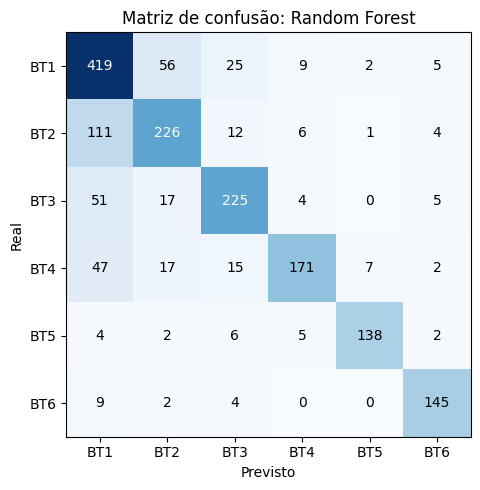

In [16]:
nome_final = tabela_teste.iloc[0]["modelo"]
pipe_final = pipelines_finais[nome_final]
previsto_final = pipe_final.predict(X_test)

print(f"Modelo final: {nome_final} (class_weight: {melhor_config[nome_final]})")
print(classification_report(y_test, previsto_final, digits=3))
plotar_matriz_confusao(y_test, previsto_final, list(pipe_final.classes_), f"Matriz de confusão: {nome_final}")

#### Interpretação

<p>No teste, o Random Forest (balanceado) tem o melhor F1 macro (0,785), o melhor PR-AUC macro (0,836) e a melhor acurácia (0,755), seguido de SVC (0,770 de F1 macro, 0,781 de PR-AUC macro), Regressão Logística (0,752 e 0,794), Árvore de Decisão (0,741 e 0,615) e LightGBM (0,731 e 0,786), com linha de base do PR-AUC macro de 0,167. O F1 macro do teste (0,785) é parecido com o da validação cruzada (0,777), então não há sinal de sobreajuste. O PR-AUC macro da Árvore de Decisão é bem menor que o dos outros porque uma árvore só gera probabilidades muito grosseiras (uma hipótese, pois não foi investigada).</p>
<p>Por classe, BT5 (F1 de 0,905) e BT6 (0,898) tem o melhor desempenho, o que é coerente com verbos muito característicos como "critique" e "design". BT2 é a classe mais difícil (F1 de 0,665 e recall de 0,628), pois fica no meio da escala, semanticamente próxima de BT1 e BT3. BT1 tem precision baixa (0,654) e recall alto (0,812), ou seja, o modelo usa BT1 como o nível para onde vão os textos de outras classes na dúvida. A matriz de confusão mostra o mesmo padrão. Isso significa que mesmo o melhor modelo erra cerca de 1 em cada 4 perguntas, e a limitação maior está no próprio rótulo (tabela da Fase 2) do que no algoritmo. Mas o ponto mais importante é a próxima seção: esse desempenho vale só para inglês.</p>

<h2>5.3 O modelo em inglês serve para texto em português?</h2>
<p>Em vez de testar uma única frase, o modelo final treinado em inglês é aplicado aos 46 casos de desenvolvimento e aos 40 casos cegos em português, e comparado com a linha de base de sempre prever a classe mais frequente do treino. Para o modelo em inglês, os casos sem verbo (rótulo BT1_default) contam como BT1, que é o que o sistema de regras também devolve como padrão.</p>

In [17]:
def acuracia_modelo_en_no_pt(casos):
    textos = [t for t, _ in casos]
    esperado = ["BT1" if r == "BT1_default" else r for _, r in casos]
    previsto = pipe_final.predict(textos)
    return accuracy_score(esperado, previsto), pd.Series(previsto).value_counts().to_dict(), esperado

classe_mais_frequente = y_train.value_counts().idxmax()
for nome_conjunto, casos in [("desenvolvimento", dev_bloom), ("cego", cego_bloom)]:
    acc, distribuicao_prevista, esperado = acuracia_modelo_en_no_pt(casos)
    linha_base = np.mean([e == classe_mais_frequente for e in esperado])
    print(f"Conjunto {nome_conjunto} ({len(casos)} casos): acurácia do modelo em inglês = {acc:.3f} | "
          f"linha de base (sempre {classe_mais_frequente}) = {linha_base:.3f}")
    print("   classes previstas:", distribuicao_prevista)

print()
print("Texto de exemplo (fotossíntese, sem verbo de comando):", pipe_final.predict([texto_exemplo])[0])
print("Frase em inglês com verbo de comando:", pipe_final.predict(["Explain why plants need sunlight to survive."])[0])

Conjunto desenvolvimento (46 casos): acurácia do modelo em inglês = 0.326 | linha de base (sempre BT1) = 0.261
   classes previstas: {'BT1': 42, 'BT4': 2, 'BT3': 1, 'BT5': 1}
Conjunto cego (40 casos): acurácia do modelo em inglês = 0.275 | linha de base (sempre BT1) = 0.225
   classes previstas: {'BT1': 37, 'BT4': 2, 'BT5': 1}

Texto de exemplo (fotossíntese, sem verbo de comando): BT1
Frase em inglês com verbo de comando: BT1


#### Interpretação

<p>O modelo treinado em inglês acerta 32,6% dos 46 casos de desenvolvimento em português e 27,5% dos 40 casos cegos, contra 26,1% e 22,5% de uma linha de base que sempre prevê BT1. Ele prevê BT1 em 42 dos 46 casos (91,3%) e em 37 dos 40 (92,5%). A diferença para a linha de base é de só 6,5 e 5 pontos percentuais, o que com 40 a 46 casos (cada caso vale 2,2 a 2,5 pontos) não se distingue de chutar sempre BT1. O texto de fotossíntese sem verbo de comando também vai para BT1.</p>
<p>O que aconteceu tem nome técnico, mudança de domínio: o vocabulário do TF-IDF é todo em inglês, então quando chega um texto em português quase nenhuma palavra é reconhecida, o vetor fica praticamente vazio e o modelo cai na classe mais frequente do treino (BT1). Isso indica que os 75,5% de acurácia medidos em inglês não valem para português, e que o modelo, mesmo sendo o melhor da comparação, não serve para o sistema. Um ponto adicional é que, mesmo em inglês, a frase "Explain why plants need sunlight to survive." também foi para BT1, o que é coerente com a tabela da Fase 2 (44% das perguntas que começam com "explain" são BT1 nesse dataset), então o modelo aprendeu o que os dados dizem, e não a regra da teoria de Bloom (explicar é BT2).</p>

<h2>5.4 Regras em português: versão inicial (V1)</h2>

In [18]:
def avaliar_regras(classificador, casos, **opcoes):
    previstos, esperados, erros = [], [], []
    for texto, esperado in casos:
        nivel, _ = classificador(texto, **opcoes)
        previsto = rotulo_curto(nivel)
        previstos.append(str(previsto))
        esperados.append(str(esperado))
        if previsto != esperado:
            erros.append((texto, esperado, previsto))
    return accuracy_score(esperados, previstos), f1_score(esperados, previstos, average="macro"), erros

resultados_v1 = {}
for nome, clf, casos, tab in [("Bloom", classificar_bloom_pt, dev_bloom, BLOOM_V1),
                              ("Simpson", classificar_simpson_pt, dev_simpson, SIMPSON_V1)]:
    acc, f1m, erros = avaliar_regras(clf, casos, tabela=tab, normalizar=False, desempate="baixo")
    resultados_v1[nome] = erros
    print(f"{nome} V1 no conjunto de desenvolvimento: acurácia {acc:.3f} | F1 macro {f1m:.3f} | {len(erros)} erros de {len(casos)}")

print()
print("Amostra de erros do Bloom V1:")
for texto, esperado, previsto in resultados_v1["Bloom"][:6]:
    print(f"  esperado={esperado:12s} previsto={str(previsto):12s} <- {texto}")

Bloom V1 no conjunto de desenvolvimento: acurácia 0.609 | F1 macro 0.656 | 18 erros de 46
Simpson V1 no conjunto de desenvolvimento: acurácia 0.773 | F1 macro 0.860 | 5 erros de 22

Amostra de erros do Bloom V1:
  esperado=BT1          previsto=BT1_default  <- Enumere as capitais da regiao Sul.
  esperado=BT1          previsto=BT1_default  <- Aponte os personagens principais do livro.
  esperado=BT1          previsto=BT1_default  <- Assinale a alternativa correta.
  esperado=BT1          previsto=BT1_default  <- Indique o ano em que o Brasil foi descoberto.
  esperado=BT2          previsto=BT1_default  <- Esclareca a diferenca entre clima e tempo.
  esperado=BT2          previsto=BT1_default  <- Reformule a frase usando sinonimos.


#### Interpretação

<p>Na primeira versão das regras, a acurácia no conjunto de desenvolvimento é de 60,9% no Bloom (18 erros em 46 casos, F1 macro de 0,656) e de 77,3% no Simpson (5 erros em 22, F1 macro de 0,860). Todos os erros de Bloom mostrados são casos em que o professor usa um verbo pedagogicamente válido que não estava na tabela (enumere, aponte, assinale, indique, esclareça, reformule), e o sistema cai no valor padrão BT1.</p>
<p>O erro tem um padrão claro (falta de cobertura do vocabulário), e não é aleatório. Isso significa que os testes de poucos exemplos, escolhidos pelo próprio autor das regras, dão uma impressão boa demais, pois tendem a usar justamente os verbos que já estão na tabela. A correção da segunda versão parte desses erros, e por isso o conjunto de desenvolvimento não pode ser usado para medir o desempenho final.</p>

<h2>5.5 Regras em português: versão corrigida (V2) no desenvolvimento e no conjunto cego</h2>

In [19]:
linhas = []
erros_cegos = {}
for nome, clf, tab_v1, tab_v2, dev, cego in [
    ("Bloom", classificar_bloom_pt, BLOOM_V1, BLOOM_V2, dev_bloom, cego_bloom),
    ("Simpson", classificar_simpson_pt, SIMPSON_V1, SIMPSON_V2, dev_simpson, cego_simpson),
]:
    configuracoes = [
        ("V1 (original)", tab_v1, dict(normalizar=False, desempate="baixo")),
        ("V2 sem remover acentos", tab_v2, dict(normalizar=False, desempate="alto")),
        ("V2 (final)", tab_v2, dict(normalizar=True, desempate="alto")),
    ]
    for versao, tab, opcoes in configuracoes:
        acc_dev, f1_dev, _ = avaliar_regras(clf, dev, tabela=tab, **opcoes)
        acc_cego, f1_cego, erros = avaliar_regras(clf, cego, tabela=tab, **opcoes)
        linhas.append({"domínio": nome, "versão": versao,
                       "acurácia desenvolvimento": acc_dev, "acurácia cego": acc_cego,
                       "F1 macro cego": f1_cego, "erros cego": len(erros)})
        if versao == "V2 (final)":
            erros_cegos[nome] = erros

tabela_regras = pd.DataFrame(linhas)
tabela_regras.round(3)

,domínio,versão,acurácia desenvolvimento,acurácia cego,F1 macro cego,erros cego
0,Bloom,V1 (original),0.609,0.575,0.603,17
1,Bloom,V2 sem remover acentos,1.000,0.625,0.646,15
2,Bloom,V2 (final),1.000,0.625,0.646,15
3,Simpson,V1 (original),0.773,0.727,0.780,6
4,Simpson,V2 sem remover acentos,1.000,0.727,0.780,6
5,Simpson,V2 (final),1.000,0.727,0.780,6


In [20]:
for nome, erros in erros_cegos.items():
    print(f"Erros da V2 final no conjunto cego de {nome} ({len(erros)} casos):")
    for texto, esperado, previsto in erros:
        print(f"  esperado={esperado:12s} previsto={str(previsto):12s} <- {texto}")
    print()

Erros da V2 final no conjunto cego de Bloom (15 casos):
  esperado=BT1          previsto=BT4          <- Relacione os países às suas capitais.
  esperado=BT1          previsto=BT1_default  <- Recorde as principais datas da Revolução Francesa.
  esperado=BT1          previsto=BT1_default  <- Diga o nome do autor de Dom Casmurro.
  esperado=BT1          previsto=BT1_default  <- Escreva a fórmula da área do círculo.
  esperado=BT2          previsto=BT1_default  <- Parafraseie o trecho do poema lido em aula.
  esperado=BT2          previsto=BT1_default  <- Ilustre com um exemplo o conceito de herança.
  esperado=BT2          previsto=BT1_default  <- Reescreva com suas palavras o problema apresentado.
  esperado=BT3          previsto=BT1_default  <- Utilize a regra de três para descobrir o valor de x.
  esperado=BT3          previsto=BT1_default  <- Empregue a fórmula de Bhaskara na equação dada.
  esperado=BT3          previsto=BT1_default  <- Determine a velocidade média do carro.
  esper

<p>O conjunto cego não tem casos com verbos que dependem de acento na tabela (como "reconheça" ou "esclareça"), por isso a remoção de acentos não muda a acurácia acima. A verificação direta abaixo mostra o efeito da correção nesses casos.</p>

In [21]:
casos_acento = [
    "Reconheça os planetas do sistema solar.",
    "Esclareça a diferença entre clima e tempo.",
    "Enumere as capitais da região Sul.",
]
for t in casos_acento:
    sem_normalizar = rotulo_curto(classificar_bloom_pt(t, normalizar=False)[0])
    normalizando = rotulo_curto(classificar_bloom_pt(t, normalizar=True)[0])
    print(f"sem remover acento: {sem_normalizar:12s} | removendo acento: {normalizando:12s} <- {t}")

sem remover acento: BT1_default  | removendo acento: BT1          <- Reconheça os planetas do sistema solar.
sem remover acento: BT1_default  | removendo acento: BT2          <- Esclareça a diferença entre clima e tempo.
sem remover acento: BT1          | removendo acento: BT1          <- Enumere as capitais da região Sul.


#### Interpretação

<p>No conjunto de desenvolvimento a segunda versão chega a 100% nos dois domínios (46 de 46 e 22 de 22), mas isso é otimista, pois os 17 verbos de Bloom e os 5 de Simpson acrescentados (de 41 para 58 e de 25 para 30) vieram dos próprios erros desse conjunto. No conjunto cego, que não foi olhado, a acurácia é de 62,5% no Bloom (25 de 40, F1 macro de 0,646) e de 72,7% no Simpson (16 de 22, F1 macro de 0,780), uma queda de 37,5 e de 27,3 pontos em relação ao desenvolvimento. A primeira versão tinha 57,5% e 72,7% no cego, então a correção melhorou só 5 pontos no Bloom (17 para 15 erros) e nada no Simpson (6 erros nas duas versões).</p>
<p>Os erros do cego confirmam a causa. No Bloom, 12 dos 15 erros são de verbos que não estão na tabela (recorde, diga, escreva, parafraseie, ilustre, reescreva, utilize, empregue, determine, proponha, planeje) e caem no padrão BT1, e os outros 3 são de ambiguidade: "relacione" é BT4 na tabela mas foi rotulado BT1 (relacionar países às capitais é memorização), "compare e contraste" foi para BT2 porque "contraste" não está na tabela, e "recomende e explique" foi para BT2 porque o verbo "explique" pesou mais que "recomende". O verbo "escreva" aparece em casos de níveis diferentes (BT1 em "escreva a fórmula" e BT6 em "escreva uma redação"), o que mostra que só o verbo às vezes não define o nível e o objeto da frase importa. No Simpson, os 6 erros são todos casos com demanda motora não detectada (escute, preste atenção, modele, cozinhe, escreva o nome, improvise): o sistema não inventou demanda motora em nenhum dos 3 casos só cognitivos, mas deixou de detectar 6 das 19 atividades com demanda motora (31,6%).</p>
<p>A remoção de acentos não muda a acurácia do cego (V2 com e sem remoção dão o mesmo resultado), porque nenhum caso do conjunto usa os verbos que dependem dela. O teste direto mostra o efeito: "Reconheça" e "Esclareça" caem no padrão sem a remoção e são reconhecidos como BT1 e BT2 com ela. Comparando com a seção anterior, as regras (62,5%) ficam bem acima do modelo em inglês (27,5%) no mesmo conjunto cego, ou seja, respondem a terceira pergunta estratégica: são melhores, mas ainda longe de confiáveis. Para o sistema, o principal impacto é que a cobertura de verbos é o gargalo, e que o resultado do sistema sempre precisa ser confirmado pelo professor, que aprova cada versão antes do aluno ver.</p>

<h1>Fase 6 Deployment</h1>
<p>Nessa fase as funções validadas são reunidas em uma única entrada (o formato que o sistema usa para passar as informações para a etapa de adaptação), e depois vêm a conclusão, a recomendação e a lista do que falta em dados para chegar em um resultado melhor.</p>

In [22]:
def analisar_atividade(texto_professor):
    nivel_bloom, pontuacao_bloom = classificar_bloom_pt(texto_professor)
    nivel_simpson, pontuacao_simpson = classificar_simpson_pt(texto_professor)
    return {
        "complexidade": avaliar_complexidade_pt(texto_professor),
        "intencao_pedagogica_bloom": nivel_bloom,
        "demanda_psicomotora_simpson": nivel_simpson,
        "verbos_bloom_detectados": {n: p for n, p in pontuacao_bloom.items() if p},
        "verbos_simpson_detectados": {n: p for n, p in pontuacao_simpson.items() if p},
    }

exemplos_finais = [
    "Explique por que as plantas precisam de luz solar para sobreviver, comparando com a respiração celular, e depois monte uma maquete do processo.",
    "Reconheça os planetas do sistema solar e recorte as figuras para colar no caderno.",
    texto_exemplo,
]
for t in exemplos_finais:
    print(json.dumps(analisar_atividade(t), ensure_ascii=False, indent=1))
    print()

{
 "complexidade": {
  "indice_flesch_pt": 52.61,
  "contagem_palavras": 23,
  "silabas_por_palavra": 2.04
 },
 "intencao_pedagogica_bloom": "BT2_entender",
 "demanda_psicomotora_simpson": "S4_mecanismo",
 "verbos_bloom_detectados": {
  "BT2_entender": 1
 },
 "verbos_simpson_detectados": {
  "S4_mecanismo": 1
 }
}

{
 "complexidade": {
  "indice_flesch_pt": 53.34,
  "contagem_palavras": 14,
  "silabas_por_palavra": 2.14
 },
 "intencao_pedagogica_bloom": "BT1_lembrar",
 "demanda_psicomotora_simpson": "S4_mecanismo",
 "verbos_bloom_detectados": {
  "BT1_lembrar": 1
 },
 "verbos_simpson_detectados": {
  "S4_mecanismo": 2
 }
}

{
 "complexidade": {
  "indice_flesch_pt": 33.32,
  "contagem_palavras": 33,
  "silabas_por_palavra": 2.15
 },
 "intencao_pedagogica_bloom": "BT1_lembrar (default)",
 "demanda_psicomotora_simpson": null,
 "verbos_bloom_detectados": {},
 "verbos_simpson_detectados": {}
}



#### Interpretação

<p>No primeiro exemplo, a atividade pede explicar e montar uma maquete e o resultado traz as duas dimensões ao mesmo tempo, de forma independente: Bloom BT2 (verbo "explique") e Simpson S4 (verbo "monte"), com índice Flesch de 52,61. No segundo, "Reconheça" é identificado como BT1 (graças à remoção de acentos) e há dois verbos motores ("recorte" e "cole") no S4. No terceiro, o texto de fotossíntese, sem verbo de comando, sai como BT1 marcado como default e sem demanda motora (None), com índice de 33,32.</p>
<p>Isso mostra o formato de saída que o motor de adaptação vai receber, e a vantagem de rastreabilidade: cada classificação vem com os verbos detectados. Uma observação sobre o primeiro exemplo é que o verbo "comparando" (gerúndio) não foi detectado, pois só entram infinitivo e imperativo, então a instrução de comparar não entrou no resultado, e isso é o tipo de limitação de cobertura que a Fase 5 mediu. Outro ponto é que o BT1 marcado como default não deve ser tratado como um BT1 de verdade pelo resto do sistema: é uma resposta do tipo "não identificado", e o professor precisa confirmar em vez de o sistema assumir memorização.</p>

<h2>Conclusão e recomendação</h2>

<p><b>O que os dados permitiram concluir, pergunta por pergunta:</b></p>
<p><b>1. Existe correlação suficiente entre uma métrica calculável de complexidade e a avaliação humana?</b> Moderada: -0,500 de Pearson e -0,532 de Spearman no CLEAR (a fórmula explica 25% da variação da nota humana). Serve como triagem para ordenar textos por dificuldade, mas não como medida precisa. O índice adaptado para o português só passou por uma verificação de bom senso com três textos, sem validação contra leitores.</p>
<p><b>2. É possível classificar a intenção pedagógica em português sem dataset de outro idioma?</b> É possível com regras de verbos, mas com desempenho modesto: 62,5% de acurácia no conjunto cego (25 de 40 casos), e não os 100% do conjunto de desenvolvimento, que é otimista porque os verbos foram cadastrados a partir dos erros dele. Doze dos 15 erros do cego são verbos que faltam na tabela.</p>
<p><b>3. As regras resolvem melhor do que o modelo treinado em inglês?</b> Sim. No mesmo conjunto cego o modelo em inglês acerta 27,5% (linha de base de 22,5%) e prevê BT1 em 92,5% dos casos, enquanto as regras acertam 62,5%. O modelo tem 0,785 de F1 macro em inglês (Random Forest), mas isso não se transfere para o português.</p>
<p><b>4. É possível identificar demanda motora sem dataset?</b> Em parte: no cego a acurácia é de 72,7% (16 de 22), sem nenhum falso positivo (os 3 casos só cognitivos foram identificados), mas 6 de 19 atividades com demanda motora (31,6%) não foram detectadas.</p>

<p><b>Recomendação do que fazer no sistema agora:</b></p>
<p><b>1.</b> Usar as regras (segunda versão) como primeira camada, sempre mostrando ao professor o verbo detectado, e nunca aplicando o resultado sem confirmação. Quando o resultado for o padrão (sem verbo reconhecido), o sistema deve dizer "não identificado" e pedir a confirmação do professor, em vez de assumir BT1.</p>
<p><b>2.</b> No Simpson, errar para o lado de sinalizar a possível demanda motora para o professor confirmar, pois deixar de detectar uma atividade motora prejudica justamente as crianças com dificuldade de coordenação, e um alarme a mais custa só uma confirmação.</p>
<p><b>3.</b> Não usar o modelo treinado em inglês no sistema. Ele fica no notebook só como evidência da mudança de domínio.</p>
<p><b>4.</b> Usar o índice de complexidade em português para ordenar e comparar versões de um mesmo texto, e não para definir corte de série ou idade até existir validação.</p>
<p><b>5.</b> Ampliar a tabela de verbos com instruções reais de professores e tratar formas verbais além do imperativo e do infinitivo (como o gerúndio), por exemplo com uma biblioteca de lematização para português.</p>

<p><b>O que falta em dados para chegar em um resultado melhor:</b></p>
<p><b>Instruções reais de professores brasileiros rotuladas por Bloom e Simpson:</b> hoje os conjuntos em português tem só 46 e 40 casos de Bloom e 22 e 22 de Simpson, com rótulos definidos por quem montou o notebook, e não por professores. Para comparação, o dataset em inglês tem 8.767 perguntas. Com dado rotulado por mais de um professor (e a concordância entre eles medida) seria possível treinar e avaliar um modelo em português de verdade.</p>
<p><b>Textos em português com nota de leitura por leitores humanos</b> (o equivalente ao CLEAR): para validar ou recalibrar o índice Flesch adaptado.</p>
<p><b>Rótulos que considerem o contexto e não só o verbo:</b> o dataset em inglês mostra que o mesmo verbo ("explain") aparece em BT1, BT2 e BT4, então o objeto da frase e o tipo de resposta esperada também definem o nível.</p>
<p><b>Retorno sobre as adaptações:</b> saber quais adaptações funcionaram para crianças com TEA, TDAH e dislexia, que é o que fecha o ciclo e permite avaliar se caracterizar o texto realmente melhora a adaptação (esta análise mede só a caracterização, e não o efeito na criança).</p>

<p><b>ESSE NOTEBOOK FOI FEITO COM IA PARA O NOSSO APRENDIZADO E CONFORTO MENTAL, ASSIM VAI FICAR CLARO QUE NÃO FOMOS NÓS QUE FIZEMOS SEM ATRAPALHAR O APRENDIZADO DELAS.</b></p>